In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error

# PyTorch Forecasting + Lightning
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer, TorchNormalizer
from pytorch_forecasting.metrics import SMAPE, RMSE, MAE, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.callbacks.progress import TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")   # utilise RTX Tensor Cores
    print("float32 matmul precision set to 'medium'")

# import pytorch_forecasting.models.base._base_model as _bm
# _orig_plot = _bm.BaseModel.log_prediction
#
# def _patched_log_prediction(self, x, out, batch_idx, **kwargs):
#     # cast any bf16 tensors in out to float32 before matplotlib touches them
#     out = {
#         k: v.float() if isinstance(v, torch.Tensor) and v.dtype == torch.bfloat16 else v
#         for k, v in out.items()
#     }
#     return _orig_plot(self, x, out, batch_idx, **kwargs)
#
# _bm.BaseModel.log_prediction = _patched_log_prediction

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'


In [16]:
# ==============================================================================
# Cell 2 – Memory-Optimization Helpers  (unchanged from original script)
# ==============================================================================
def smallest_int_dtype(min_val: int, max_val: int, signed: bool = True) -> str:
    if signed:
        if np.iinfo(np.int8).min <= min_val <= max_val <= np.iinfo(np.int8).max:
            return "int8"
        if np.iinfo(np.int16).min <= min_val <= max_val <= np.iinfo(np.int16).max:
            return "int16"
        if np.iinfo(np.int32).min <= min_val <= max_val <= np.iinfo(np.int32).max:
            return "int32"
        return "int64"
    else:
        if 0 <= min_val <= max_val <= np.iinfo(np.uint8).max:
            return "uint8"
        if 0 <= min_val <= max_val <= np.iinfo(np.uint16).max:
            return "uint16"
        if 0 <= min_val <= max_val <= np.iinfo(np.uint32).max:
            return "uint32"
        return "uint64"


def optimize_df_for_memory(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Converts columns to smaller dtypes.
    For low-decimal float columns, stores scaled integers if that beats float32.
    Returns:
        optimized_df
        metadata dict with scaling info
    """
    meta = {}

    for col in df.columns:
        s = df[col]

        unique_non_null = set(df[col].dropna().unique())
        if unique_non_null.issubset({0, 1, True, False}):
            if col == "Група":
                df[col] = s.astype("bool")
                meta[col] = {"stored_as": "bool", "scale": 1}
                continue

        if pd.api.types.is_integer_dtype(s):
            mn, mx = int(s.min()), int(s.max())
            dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
            df[col] = s.astype(dtype)
            meta[col] = {"stored_as": dtype, "scale": 1}
            continue

        if pd.api.types.is_float_dtype(s):
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}
                continue

            decimals = non_null.astype(str).apply(
                lambda x: len(x.split(".")[1].rstrip("0")) if "." in x else 0
            ).max()

            if decimals <= 3:
                scale = 10 ** decimals
                scaled = np.round(s * scale)
                mn = int(np.nanmin(scaled))
                mx = int(np.nanmax(scaled))
                int_dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
                int_bytes = np.dtype(int_dtype).itemsize
                float32_bytes = np.dtype("float32").itemsize
                if int_bytes < float32_bytes:
                    df[col] = scaled.astype(int_dtype)
                    meta[col] = {"stored_as": int_dtype, "scale": scale}
                else:
                    df[col] = s.astype("float32")
                    meta[col] = {"stored_as": "float32", "scale": 1}
            else:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}

    return df, meta


In [17]:
# ==============================================================================
# Cell 3 – Metric Helpers  (unchanged from original script)
# ==============================================================================
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / np.maximum(denom, 1e-8))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


In [30]:
# ==============================================================================
# Cell 4 – Configuration  ← adjust these before running
# ==============================================================================

# ── Paths ──────────────────────────────────────────────────────────────────────
TRAIN_PATH = "data/money_calc/train.parquet"
VAL_PATH   = "data/money_calc/val.parquet"
TEST_PATH  = "data/money_calc/test.parquet"

# ── Target ─────────────────────────────────────────────────────────────────────
Y_COL = "Money_spent"

# ── Station identifier column ──────────────────────────────────────────────────
# PyTorch Forecasting needs a single string column that identifies each time series.
# We will derive it from the one-hot EIC columns below (see Cell 5).
GROUP_COL = "station_id"

# ── Forecasting horizon & encoder length ───────────────────────────────────────
# Predict this many hours ahead
MAX_PREDICTION_LENGTH = 24          # 24 h forecast
MAX_ENCODER_LENGTH    = 36    # look-back window: 7 days

# ── Training hyper-parameters ──────────────────────────────────────────────────
BATCH_SIZE    = 1024 * 2
MAX_EPOCHS    = 50
LEARNING_RATE = 3e-3
HIDDEN_SIZE            = 32   # was 64
ATTENTION_HEAD_SIZE    = 2    # was 4
HIDDEN_CONTINUOUS_SIZE = 16   # was 32
DROPOUT       = 0.1

# ── Numerical real-valued covariates known at forecast time (time-varying) ─────
FUTURE_REALS = [
    "temperature_2m", "apparent_temperature", "dew_point_2m",
    "relative_humidity_2m", "precipitation", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "surface_pressure", "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m",
    "shortwave_radiation", "diffuse_radiation", "direct_normal_irradiance",
    # removed: Hour, day_of_week, season_number, Month, Day
    # these are now handled by TIME_VARYING_KNOWN_CATS below
    "Average of Ціна розподілу ЕЕ грн_ без ПДВ/кВт*год",
    "Average of Ціна ЕЕ грн_ без ПДВ/кВт*год",
]

# ── Numerical real-valued covariates NOT known at forecast time ─────────────────
PAST_REALS = []   # add any columns that are only available historically

# ── Static numerical covariates (one value per station, time-invariant) ─────────
STATIC_REALS = [
    "GPS-координати - Широта",
    "GPS-координати - Довгота",
]

# ── Categorical time-varying known covariates ───────────────────────────────────
# Calendar categoricals — always known in the future
TIME_VARYING_KNOWN_CATS = [
    "Month_cat", "Day_cat", "Hour_cat", "day_of_week_cat", "season_cat"
]  # created in Cell 5

# ── Static categoricals ─────────────────────────────────────────────────────────
# One-hot encoded columns will be collapsed back to a single categorical.
# Any remaining OHE groups (Тип, Область, …) are handled similarly.
STATIC_CATS = ["station_id", "Тип_cat", "Область_cat"]   # created in Cell 5


In [31]:
# ==============================================================================
# Cell 5 – Load & Pre-process Data
# ==============================================================================

def recover_station_id(df: pd.DataFrame) -> pd.DataFrame:
    """
    The 400 'EIC-код_<station>' columns are one-hot encoded.
    Collapse them into a single station_id string column.
    """
    eic_cols = [c for c in df.columns if c.startswith("EIC-код_")]
    # argmax across OHE columns → station name
    df[GROUP_COL] = df[eic_cols].idxmax(axis=1).str.replace("EIC-код_", "", regex=False)
    df = df.drop(columns=eic_cols)
    return df


def recover_ohe_cat(df: pd.DataFrame, prefix: str, new_col: str) -> pd.DataFrame:
    """
    Collapse a set of OHE columns back to a single categorical column.
    prefix  – common column prefix, e.g. 'Тип_'
    new_col – name for the resulting categorical column
    """
    ohe_cols = [c for c in df.columns if c.startswith(prefix)]
    if not ohe_cols:
        return df
    df[new_col] = df[ohe_cols].idxmax(axis=1).str.replace(prefix, "", regex=False)
    df = df.drop(columns=ohe_cols)
    return df


def build_time_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    PyTorch Forecasting requires a monotonically increasing integer time_idx
    that is *shared* across all groups (think of it as the global hour counter).
    """
    df["datetime"] = pd.to_datetime(
        df[["Year", "Month", "Day", "Hour"]].rename(
            columns={"Year": "year", "Month": "month", "Day": "day", "Hour": "hour"}
        )
    )
    # Global hourly index starting from the minimum timestamp in the dataset
    min_dt = df["datetime"].min()
    df["time_idx"] = ((df["datetime"] - min_dt).dt.total_seconds() / 3600).astype(int)
    return df


def add_cat_helpers(df: pd.DataFrame) -> pd.DataFrame:
    """Create string categoricals from numerics for PyTorch Forecasting."""
    df["Month_cat"]       = df["Month"].astype(str)
    df["day_of_week_cat"] = df["day_of_week"].astype(str)
    df["season_cat"]      = df["season_number"].astype(str)
    return df


DROP_PREFIXES = ("АЗС_", "ОСР код_", "ОСР опис_")

def drop_prefix_cols(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = [c for c in df.columns if c.startswith(DROP_PREFIXES)]
    print(f"  Dropping {len(cols_to_drop)} prefix-matched columns")
    return df.drop(columns=cols_to_drop)


def add_cat_helpers(df: pd.DataFrame) -> pd.DataFrame:
    """Create string categoricals from numerics for PyTorch Forecasting."""
    df["Month_cat"]       = df["Month"].astype(str)
    df["Day_cat"]         = df["Day"].astype(str)
    df["Hour_cat"]        = df["Hour"].astype(str)
    df["day_of_week_cat"] = df["day_of_week"].astype(str)
    df["season_cat"]      = df["season_number"].astype(str)
    return df


def load_and_prepare(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path).reset_index(drop=True)

    df.columns = df.columns.str.replace('.', '_', regex=False)
    df, _ = optimize_df_for_memory(df)

    # Cast compressed ints back to float32 for PTF
    for col in df.select_dtypes(
        include=["int8","int16","int32","uint8","uint16","uint32"]
    ).columns:
        if col not in ["Year","Month","Day","Hour","day_of_week","season_number"]:
            df[col] = df[col].astype("float32")

    # Drop junk OHE columns before anything else
    df = drop_prefix_cols(df)

    df = recover_station_id(df)
    df = recover_ohe_cat(df, prefix="Тип_",     new_col="Тип_cat")
    df = recover_ohe_cat(df, prefix="Область_", new_col="Область_cat")
    df = build_time_index(df)
    df = add_cat_helpers(df)

    # # Filter to data from 2024-09-01 onwards
    df = df[df["datetime"] >= "2024-07-10"].reset_index(drop=True)

    df[Y_COL] = df[Y_COL].astype("float32")
    df = df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)

    return df


print("Loading train …")
train = load_and_prepare(TRAIN_PATH)

# Compute global min datetime from train so val/test share the same time_idx origin
GLOBAL_MIN_DT = train["datetime"].min()

print("Loading val   …")
val = load_and_prepare(VAL_PATH)

print("Loading test  …")
test = load_and_prepare(TEST_PATH)

# Align time_idx to the same global origin across splits
for split in [val, test]:
    split["time_idx"] = ((split["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600).astype(int)

print(f"\nTrain shape : {train.shape}")
print(f"Val   shape : {val.shape}")
print(f"Test  shape : {test.shape}")
print(f"\nStations in train : {train[GROUP_COL].nunique()}")
print(f"time_idx range    : [{train['time_idx'].min()}, {train['time_idx'].max()}]")

Loading train …
  Dropping 157 prefix-matched columns
Loading val   …
  Dropping 157 prefix-matched columns
Loading test  …
  Dropping 157 prefix-matched columns

Train shape : (3224230, 40)
Val   shape : (304499, 40)
Test  shape : (304152, 40)

Stations in train : 408
time_idx range    : [4583, 13126]


In [32]:
# Station diagnostics — run before deciding which to cut
station_stats = (
    train.groupby(GROUP_COL)
    .agg(
        rows=(Y_COL, "count"),
        hours_span=("time_idx", lambda x: x.max() - x.min()),
        missing_pct=("time_idx", lambda x: 1 - len(x) / (x.max() - x.min() + 1)),
        target_mean=(Y_COL, "mean"),
        target_std=(Y_COL, "std"),
        target_zeros=(Y_COL, lambda x: (x == 0).mean()),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

print(f"Total stations: {len(station_stats)}")
print(f"\nTop 10 largest:")
print(station_stats.head(10).to_string())
print(f"\nBottom 10 smallest:")
print(station_stats.tail(10).to_string())
print(f"\nStations with >50% missing: {(station_stats.missing_pct > 0.5).sum()}")
print(f"Stations with >50% zeros  : {(station_stats.target_zeros > 0.5).sum()}")
print(f"Stations with <100 rows   : {(station_stats.rows < 100).sum()}")

Total stations: 408

Top 10 largest:
           station_id  rows  hours_span  missing_pct  target_mean  target_std  target_zeros
0    62Z0008583037334  8543        8543     0.000117   172.163116   43.034962      0.000000
259  62Z6070434707477  8543        8543     0.000117   157.028549   38.818211      0.000000
269  62Z6337618908569  8543        8543     0.000117    90.108482   29.581688      0.000000
268  62Z6308545383007  8543        8543     0.000117    87.902588   39.339725      0.000000
267  62Z6295419983830  8543        8543     0.000117   116.242073   38.524826      0.000000
266  62Z6235725021728  8543        8543     0.000117    92.997475   21.681471      0.000000
265  62Z6186862204513  8543        8543     0.000117   114.954926   44.442078      0.001873
263  62Z6136241721979  8543        8543     0.000117   120.861282   37.339958      0.000000
262  62Z6091309944129  8543        8543     0.000117    77.269920   57.510468      0.000000
261  62Z6084896400004  8543        8543    

In [33]:
TARGET_STATIONS = 100

np.random.seed(42)

sampled_stations = station_stats.sample(
    n=TARGET_STATIONS, random_state=42
)[GROUP_COL].values

print(f"Stations kept: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows     : {len(train):,}")
print(f"Train batches  : {len(train) // BATCH_SIZE}")

Stations kept: 100
Train rows     : 781,932
Train batches  : 381


In [34]:
train

,Year,Month,Day,Hour,Average of Ціна розподілу ЕЕ грн_ без ПДВ/кВт*год,Average of Ціна ЕЕ грн_ без ПДВ/кВт*год,GPS-координати - Широта,GPS-координати - Довгота,temperature_2m,apparent_temperature,...,station_id,Тип_cat,Область_cat,datetime,time_idx,Month_cat,Day_cat,Hour_cat,day_of_week_cat,season_cat
0,2024,7,9,24,2.15221,5.732343,48.442429,22.192190,234.0,268.0,...,62Z0008583037334,ОККО-комплекс,Закарпатська,2024-07-10 00:00:00,4583,7,9,24,2,3
1,2024,7,10,1,2.15221,5.732343,48.442429,22.192190,225.0,259.0,...,62Z0008583037334,ОККО-комплекс,Закарпатська,2024-07-10 01:00:00,4584,7,10,1,2,3
2,2024,7,10,2,2.15221,5.732343,48.442429,22.192190,218.0,246.0,...,62Z0008583037334,ОККО-комплекс,Закарпатська,2024-07-10 02:00:00,4585,7,10,2,2,3
3,2024,7,10,3,2.15221,5.732343,48.442429,22.192190,217.0,246.0,...,62Z0008583037334,ОККО-комплекс,Закарпатська,2024-07-10 03:00:00,4586,7,10,3,2,3
4,2024,7,10,4,2.15221,5.732343,48.442429,22.192190,217.0,243.0,...,62Z0008583037334,ОККО-комплекс,Закарпатська,2024-07-10 04:00:00,4587,7,10,4,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781927,2025,6,30,19,1.70713,4.883898,50.419476,29.842367,180.0,139.0,...,62Z9972124228553,ОККО-комплекс,Київська,2025-06-30 19:00:00,13122,6,30,19,0,3
781928,2025,6,30,20,1.70713,4.883898,50.419476,29.842367,146.0,121.0,...,62Z9972124228553,ОККО-комплекс,Київська,2025-06-30 20:00:00,13123,6,30,20,0,3
781929,2025,6,30,21,1.70713,4.883898,50.419476,29.842367,148.0,113.0,...,62Z9972124228553,ОККО-комплекс,Київська,2025-06-30 21:00:00,13124,6,30,21,0,3
781930,2025,6,30,22,1.70713,4.883898,50.419476,29.842367,148.0,119.0,...,62Z9972124228553,ОККО-комплекс,Київська,2025-06-30 22:00:00,13125,6,30,22,0,3


In [10]:
# ==============================================================================
# Cell 6 – Build PyTorch Forecasting Datasets
# ==============================================================================

# Combine train + val so the val dataset can reference the encoder look-back
# that might overlap with train rows.  We use the standard pattern:
#   training_cutoff = max time_idx in train
training_cutoff = train["time_idx"].max()

# Concatenate for creating the datasets (PTF handles the split internally)
data_full = pd.concat([train, val], ignore_index=True).sort_values(
    [GROUP_COL, "time_idx"]
).reset_index(drop=True)

# ── Sanity-check required columns exist ────────────────────────────────────────
missing = [
    c for c in FUTURE_REALS + PAST_REALS + STATIC_REALS
    + TIME_VARYING_KNOWN_CATS + STATIC_CATS
    if c not in data_full.columns
]
if missing:
    print("⚠️  Missing columns (remove from config or add to pre-processing):")
    for m in missing:
        print("   ", m)
else:
    print("✅  All configured columns present.")

# Filter to only existing columns
def filter_existing(lst, df):
    return [c for c in lst if c in df.columns]

future_reals_ok       = filter_existing(FUTURE_REALS, data_full)
past_reals_ok         = filter_existing(PAST_REALS,   data_full)
static_reals_ok       = filter_existing(STATIC_REALS, data_full)
tv_known_cats_ok      = filter_existing(TIME_VARYING_KNOWN_CATS, data_full)
static_cats_ok        = filter_existing(STATIC_CATS,  data_full)

# ── Training dataset ───────────────────────────────────────────────────────────
training = TimeSeriesDataSet(
    data_full[data_full["time_idx"] <= training_cutoff],
    time_idx                  = "time_idx",
    target                    = Y_COL,
    group_ids                 = [GROUP_COL],
    min_encoder_length        = MAX_ENCODER_LENGTH // 2,   # allow shorter look-backs
    max_encoder_length        = MAX_ENCODER_LENGTH,
    min_prediction_length     = 1,
    max_prediction_length     = MAX_PREDICTION_LENGTH,
    static_categoricals       = static_cats_ok,
    static_reals              = static_reals_ok,
    time_varying_known_reals  = future_reals_ok + ["time_idx"],
    time_varying_known_categoricals = tv_known_cats_ok,
    time_varying_unknown_reals = [Y_COL] + past_reals_ok,
    target_normalizer         = GroupNormalizer(
        groups=[GROUP_COL], transformation="softplus"
    ),
    add_relative_time_idx     = True,
    add_target_scales         = True,
    add_encoder_length        = True,
    allow_missing_timesteps   = True,   # stations may have gaps
)

# ── Validation dataset – shares the same parameters as training ────────────────
validation = TimeSeriesDataSet.from_dataset(
    training,
    data_full,
    predict=True,           # only the prediction window beyond training_cutoff
    stop_randomization=True,
)

# ── DataLoaders ────────────────────────────────────────────────────────────────
NUM_WORKERS = 10  # adjust to your CPU count

train_loader = training.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,   # ← don't kill/respawn workers each epoch
    prefetch_factor=4,         # ← pre-stage 4 batches per worker
)
val_loader = validation.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE * 4,  # validation has no backward pass, push it harder
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)

print(f"\nTraining   batches : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")

✅  All configured columns present.

Training   batches : 453
Validation batches : 1


In [12]:
# ==============================================================================
# Cell 7 – Build the TFT / LSTM Model
# ==============================================================================
# PyTorch Forecasting's TemporalFusionTransformer uses LSTMs internally as
# its sequence encoder/decoder – it is the recommended "LSTM +" architecture
# for multi-series panel forecasting with covariates.
# If you strictly need a vanilla LSTM, swap TFT for
# pytorch_forecasting.models.DeepAR or pytorch_forecasting.models.NHiTS.

from pytorch_forecasting.metrics import RMSE

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = LEARNING_RATE,
    hidden_size            = HIDDEN_SIZE,
    attention_head_size    = ATTENTION_HEAD_SIZE,
    dropout                = DROPOUT,
    hidden_continuous_size = HIDDEN_CONTINUOUS_SIZE,
    loss                   = RMSE(),        # ← was QuantileLoss()
    log_interval           = -1,
    optimizer              = "adam",
    reduce_on_plateau_patience = 4,
)

print(f"Number of parameters: {tft.size() / 1e3:.1f}k")

# tft = torch.compile(tft)

Number of parameters: 177.8k


In [13]:
early_stop = EarlyStopping(
    monitor   = "val_loss",
    min_delta = 1e-4,
    patience  = 5,
    verbose   = True,
    mode      = "min",
)

lr_logger = LearningRateMonitor()

checkpoint = ModelCheckpoint(
    dirpath   = "checkpoints/",
    filename  = "tft-{epoch:02d}-{val_loss:.4f}",
    monitor   = "val_loss",
    mode      = "min",
    save_top_k = 2,
)

# TQDMProgressBar renders correctly inside Jupyter notebooks.
# refresh_rate controls how often (in batches) the bar updates.
progress_bar = TQDMProgressBar(refresh_rate=20)

logger = TensorBoardLogger("tb_logs", name="tft_gas_stations")

trainer = pl.Trainer(
    max_epochs           = MAX_EPOCHS,
    accelerator          = "gpu" if torch.cuda.is_available() else "cpu",
    devices              = 1,
    gradient_clip_val    = 0.1,
    callbacks            = [early_stop, lr_logger, checkpoint, progress_bar],
    logger               = logger,
    enable_progress_bar  = True,
    log_every_n_steps    = 10,
    precision="bf16-mixed",
    val_check_interval=0.25,           # validate 4× per epoch instead of once
    accumulate_grad_batches=4,
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [14]:
# ==============================================================================
# Cell 9 – Train
# ==============================================================================

trainer.fit(
    tft,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

print(f"\nBest checkpoint : {checkpoint.best_model_path}")
print(f"Best val_loss   : {checkpoint.best_model_score:.6f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ RMSE                            │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  3.0 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    896 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 10.6 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 57.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 54.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     33 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 177 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 177 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 945                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 5 records. Best score: 6.318. Signaling Trainer to stop.



Best checkpoint : C:\Users\Lev\Documents\GitHub\Diploma\checkpoints\tft-epoch=07-val_loss=6.3180.ckpt
Best val_loss   : 6.317999


In [15]:
# Quick epoch time breakdown
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Train samples : {len(training)}")
print(f"Val   samples : {len(validation)}")
print(f"Stations      : {train[GROUP_COL].nunique()}")
print(f"Encoder len   : {MAX_ENCODER_LENGTH}")
print(f"Prediction len: {MAX_PREDICTION_LENGTH}")

Train batches : 453
Val   batches : 1
Batch size    : 2048
Train samples : 927806
Val   samples : 100
Stations      : 100
Encoder len   : 36
Prediction len: 24


In [23]:
# ==============================================================================
# Cell 10 – Load Best Checkpoint & Validate
# ==============================================================================

best_tft = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint.best_model_path,
    weights_only=False,
)
best_tft.eval()

result = best_tft.predict(
    val_loader,
    return_index=True,
    trainer_kwargs={"accelerator": "gpu" if torch.cuda.is_available() else "cpu"},
)

# result[0]: (100, 24) — one row per station, 24 prediction steps
# result[2]: (100, 2)  — one row per station with GROUP_COL + time_idx (start of window)
pred_tensor = result[0].cpu().numpy()  # (100, 24)
val_index = result[2]  # (100, 2)

# Expand index: for each station repeat across all 24 prediction steps
rows = []
for i, (_, idx_row) in enumerate(val_index.iterrows()):
    for step in range(MAX_PREDICTION_LENGTH):
        rows.append({
            GROUP_COL: idx_row[GROUP_COL],
            "time_idx": idx_row["time_idx"] + step,
            "pred": pred_tensor[i, step],
        })

val_expanded = pd.DataFrame(rows)

# Merge with ground truth
val_merged = val_expanded.merge(
    data_full[[GROUP_COL, "time_idx", Y_COL]],
    on=[GROUP_COL, "time_idx"],
    how="inner",
)

val_pred = val_merged["pred"].values
val_true = val_merged[Y_COL].values

print(f"Aligned samples: {len(val_true)}")
print("\n── Validation Metrics ──────────────────────────────────────")
print(f"SMAPE : {smape(val_true, val_pred):.4f}")
print(f"RMSE  : {rmse(val_true, val_pred):.4f}")
print(f"MAPE  : {mape(val_true, val_pred):.2f} %")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Aligned samples: 2400

── Validation Metrics ──────────────────────────────────────
SMAPE : 0.0420
RMSE  : 6.3238
MAPE  : 4.26 %


In [21]:
len(val_true)

100

In [22]:
len(val_pred)

2400

In [25]:
# ==============================================================================
# Cell 11 – Build Test Dataset & Run Inference
# ==============================================================================

val_cutoff = data_full["time_idx"].max()

data_all = pd.concat([data_full, test], ignore_index=True).sort_values(
    [GROUP_COL, "time_idx"]
).reset_index(drop=True)

test_dataset = TimeSeriesDataSet.from_dataset(
    training,
    data_all,
    predict=True,
    stop_randomization=True,
)

test_loader = test_dataset.to_dataloader(
    train=False, batch_size=BATCH_SIZE * 2, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True,
)

result = best_tft.predict(
    test_loader,
    return_index=True,
    trainer_kwargs={"accelerator": "gpu" if torch.cuda.is_available() else "cpu"},
)

pred_tensor = result[0].cpu().numpy()  # (n_stations, 24)
test_index = result[2]  # (n_stations, 2)

# Expand index across all 24 prediction steps
rows = []
for i, (_, idx_row) in enumerate(test_index.iterrows()):
    for step in range(MAX_PREDICTION_LENGTH):
        rows.append({
            GROUP_COL: idx_row[GROUP_COL],
            "time_idx": idx_row["time_idx"] + step,
            "pred": pred_tensor[i, step],
        })

test_expanded = pd.DataFrame(rows)

test_merged = test_expanded.merge(
    data_all[[GROUP_COL, "time_idx", Y_COL]],
    on=[GROUP_COL, "time_idx"],
    how="inner",
)

test_pred = test_merged["pred"].values
test_true = test_merged[Y_COL].values

print(f"Aligned samples: {len(test_true)}")
print("\n── Test Metrics ────────────────────────────────────────────")
print(f"SMAPE : {smape(test_true, test_pred):.4f}")
print(f"RMSE  : {rmse(test_true, test_pred):.4f}")
print(f"MAPE  : {mape(test_true, test_pred):.2f} %")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Aligned samples: 2400

── Test Metrics ────────────────────────────────────────────
SMAPE : 0.0420
RMSE  : 6.3238
MAPE  : 4.26 %


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Val aligned samples: 2328

── Validation Metrics ──────────────────────────────────────
SMAPE : 0.0673
RMSE  : 16.6040
MAPE  : 7.02 %


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Test aligned samples: 2304

── Test Metrics ────────────────────────────────────────────
SMAPE : 0.0727
RMSE  : 18.6829
MAPE  : 7.03 %


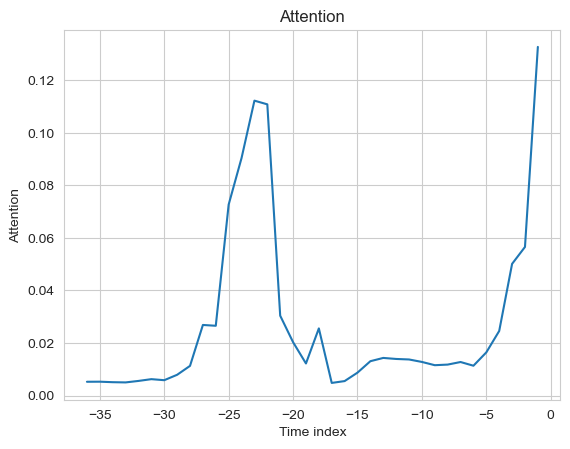

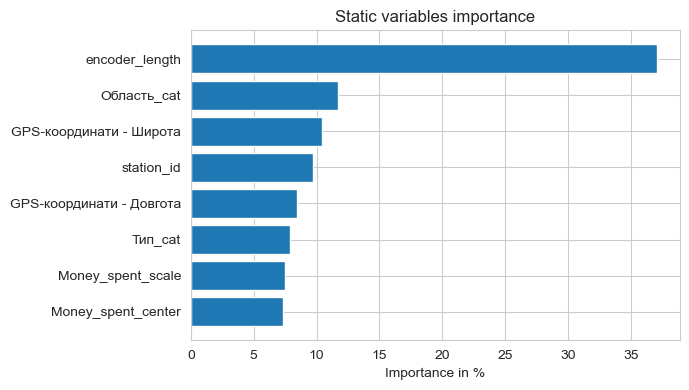

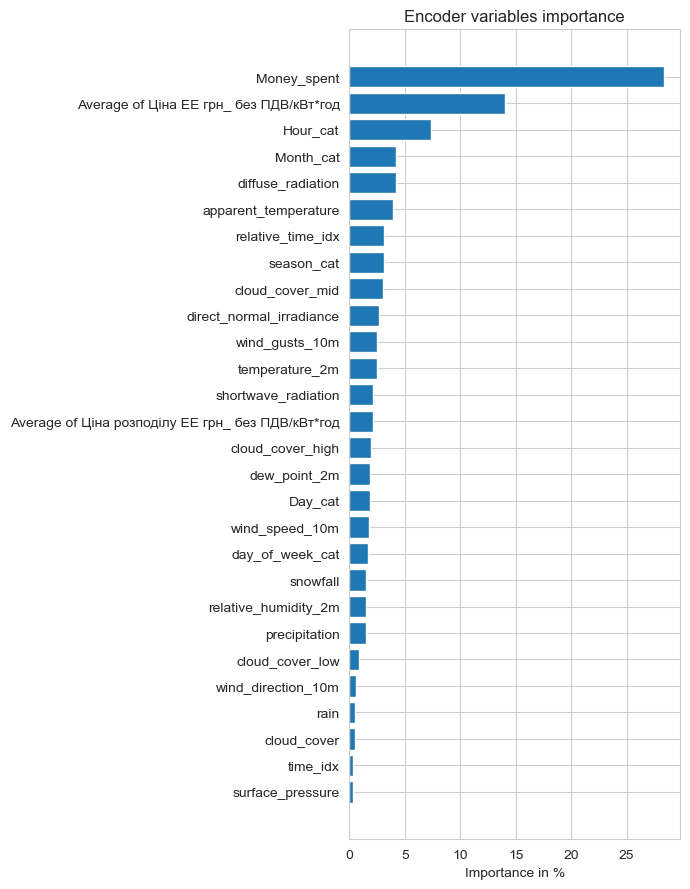

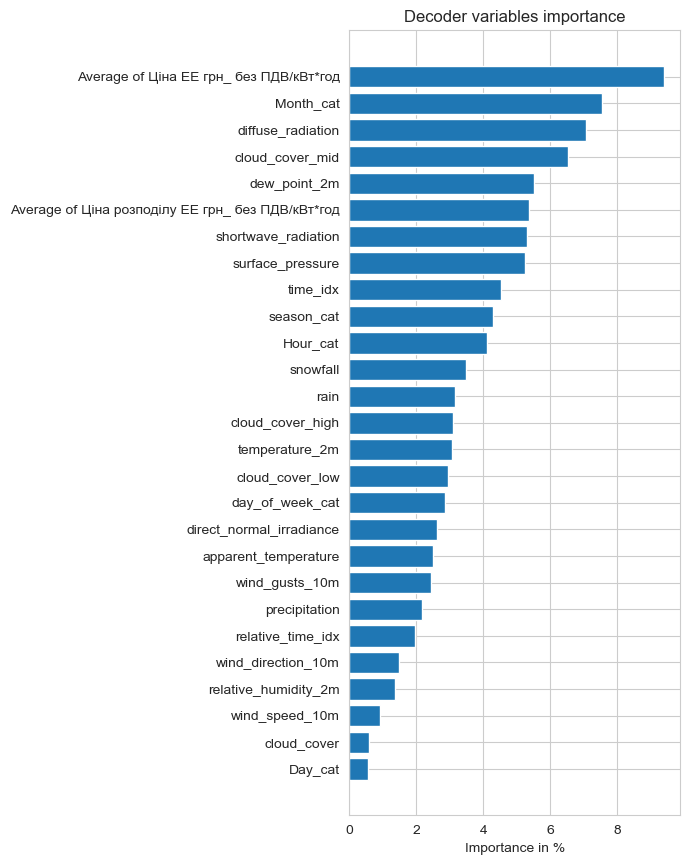

Variable importance plot saved to variable_importance.png


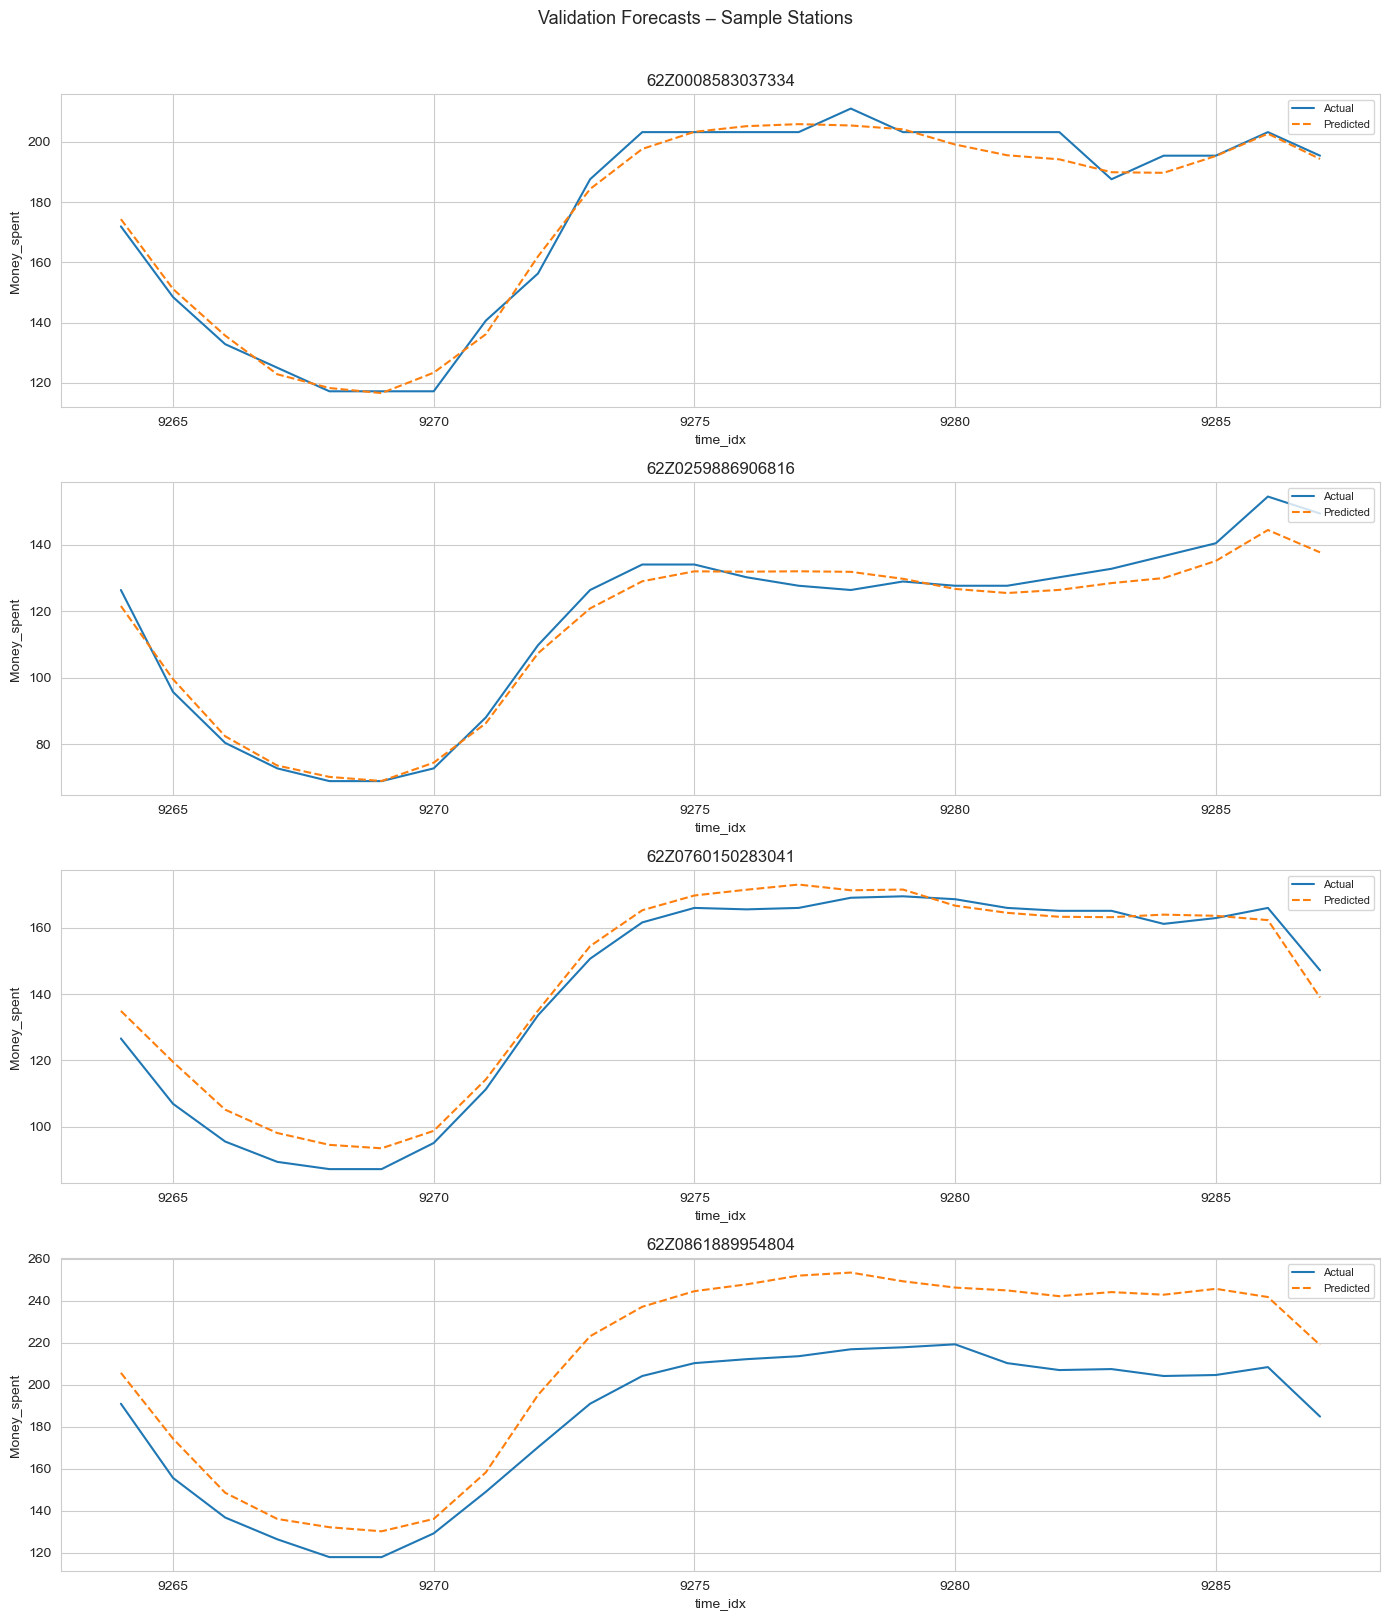

Sample forecast plot saved to sample_forecasts.png
val_predictions.csv  written.
test_predictions.csv written.


In [26]:
# ==============================================================================
# Cell 10 – Load Best Checkpoint
# ==============================================================================

best_tft = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint.best_model_path,
    weights_only=False,
)
best_tft.eval()


def predict_and_align(model, loader, reference_df):
    """
    Run inference and align predictions with ground truth.
    reference_df must contain GROUP_COL, time_idx, and Y_COL.
    Returns a merged DataFrame with columns: GROUP_COL, time_idx, Y_COL, pred.
    """
    result = model.predict(
        loader,
        return_index=True,
        trainer_kwargs={"accelerator": "gpu" if torch.cuda.is_available() else "cpu"},
    )

    pred_tensor = result[0].cpu().numpy()  # (n_stations, 24)
    index_df = result[2]  # (n_stations, 2)

    rows = []
    for i, (_, idx_row) in enumerate(index_df.iterrows()):
        for step in range(MAX_PREDICTION_LENGTH):
            rows.append({
                GROUP_COL: idx_row[GROUP_COL],
                "time_idx": idx_row["time_idx"] + step,
                "pred": pred_tensor[i, step],
            })

    expanded = pd.DataFrame(rows)

    merged = expanded.merge(
        reference_df[[GROUP_COL, "time_idx", Y_COL]],
        on=[GROUP_COL, "time_idx"],
        how="inner",
    )
    return merged


# ==============================================================================
# Cell 11 – Validate on Val set only
# ==============================================================================

# Val dataset built purely from val — no train rows needed for context because
# PTF uses the encoder window which is already in the val split
val_dataset_eval = TimeSeriesDataSet.from_dataset(
    training,
    val,  # only val rows
    predict=True,
    stop_randomization=True,
)

val_loader_eval = val_dataset_eval.to_dataloader(
    train=False, batch_size=BATCH_SIZE * 2,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
)

val_merged = predict_and_align(best_tft, val_loader_eval, val)

val_pred = val_merged["pred"].values
val_true = val_merged[Y_COL].values

print(f"Val aligned samples: {len(val_true)}")
print("\n── Validation Metrics ──────────────────────────────────────")
print(f"SMAPE : {smape(val_true, val_pred):.4f}")
print(f"RMSE  : {rmse(val_true, val_pred):.4f}")
print(f"MAPE  : {mape(val_true, val_pred):.2f} %")

# ==============================================================================
# Cell 12 – Test on Test set only
# ==============================================================================

test_dataset_eval = TimeSeriesDataSet.from_dataset(
    training,
    test,  # only test rows
    predict=True,
    stop_randomization=True,
)

test_loader_eval = test_dataset_eval.to_dataloader(
    train=False, batch_size=BATCH_SIZE * 2,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
)

test_merged = predict_and_align(best_tft, test_loader_eval, test)

test_pred = test_merged["pred"].values
test_true = test_merged[Y_COL].values

print(f"Test aligned samples: {len(test_true)}")
print("\n── Test Metrics ────────────────────────────────────────────")
print(f"SMAPE : {smape(test_true, test_pred):.4f}")
print(f"RMSE  : {rmse(test_true, test_pred):.4f}")
print(f"MAPE  : {mape(test_true, test_pred):.2f} %")

# ==============================================================================
# Cell 13 – Variable Importance
# ==============================================================================
import matplotlib.pyplot as plt

# Re-run raw prediction to get the output dict needed for interpretation
raw_result = best_tft.predict(
    val_loader_eval,
    mode="raw",
    return_index=True,
    trainer_kwargs={"accelerator": "gpu" if torch.cuda.is_available() else "cpu"},
)

interpretation = best_tft.interpret_output(
    raw_result[0], reduction="sum"
)

best_tft.plot_interpretation(interpretation)
plt.tight_layout()
plt.savefig("variable_importance.png", dpi=150)
plt.show()
print("Variable importance plot saved to variable_importance.png")

# ==============================================================================
# Cell 14 – Per-station Forecast Plot (sample 4 stations)
# ==============================================================================

sample_stations = val_merged[GROUP_COL].unique()[:4]

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)

for ax, station in zip(axes, sample_stations):
    subset = val_merged[val_merged[GROUP_COL] == station].sort_values("time_idx")

    if subset.empty:
        ax.set_title(f"{station} – no val data")
        continue

    ax.plot(subset["time_idx"].values, subset[Y_COL].values,
            label="Actual", color="#1f77b4")
    ax.plot(subset["time_idx"].values, subset["pred"].values,
            label="Predicted", color="#ff7f0e", linestyle="--")
    ax.set_title(station)
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylabel(Y_COL)
    ax.set_xlabel("time_idx")

plt.suptitle("Validation Forecasts – Sample Stations", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("sample_forecasts.png", dpi=150)
plt.show()
print("Sample forecast plot saved to sample_forecasts.png")

# ==============================================================================
# Cell 15 – Save Predictions to CSV
# ==============================================================================

val_merged.to_csv("val_predictions.csv", index=False)
test_merged.to_csv("test_predictions.csv", index=False)

print("val_predictions.csv  written.")
print("test_predictions.csv written.")

In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import glob
import os

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
import matplotlib.pyplot as plt

# ==============================================================================
# Configuration  — must match what you used during training exactly
# ==============================================================================

TRAIN_PATH  = "data/money_calc/train.parquet"
VAL_PATH    = "data/money_calc/val.parquet"
inference_path  = "data/no_y_col/with_weather.parquet"

# Point this to your checkpoint file.
# Option A: explicit path
CHECKPOINT_PATH = None   # e.g. "checkpoints/tft-epoch=07-val_loss=12.3456.ckpt"
# Option B: auto-find the bestad (lowest val_loss) checkpoint in the folder
CHECKPOINT_DIR  = "checkpoints/"

Y_COL             = "Money_spent"
GROUP_COL         = "station_id"
MAX_PREDICTION_LENGTH = 24
MAX_ENCODER_LENGTH    = 36
BATCH_SIZE            = 1024 * 2
NUM_WORKERS           = 10

FUTURE_REALS = [
    "temperature_2m", "apparent_temperature", "dew_point_2m",
    "relative_humidity_2m", "precipitation", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "surface_pressure", "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m",
    "shortwave_radiation", "diffuse_radiation", "direct_normal_irradiance",
    "Average of Ціна розподілу ЕЕ грн_ без ПДВ/кВт*год",
    "Average of Ціна ЕЕ грн_ без ПДВ/кВт*год",
]
STATIC_REALS          = ["GPS-координати - Широта", "GPS-координати - Довгота"]
TIME_VARYING_KNOWN_CATS = ["Month_cat", "Day_cat", "Hour_cat", "day_of_week_cat", "season_cat"]
STATIC_CATS           = ["station_id", "Тип_cat", "Область_cat"]
DROP_PREFIXES         = ("АЗС_", "ОСР код_", "ОСР опис_")


# ==============================================================================
# Helpers  (copied verbatim from your training script)
# ==============================================================================

def smallest_int_dtype(min_val, max_val, signed=True):
    if signed:
        for t in ["int8", "int16", "int32"]:
            info = np.iinfo(t)
            if info.min <= min_val <= max_val <= info.max:
                return t
        return "int64"
    else:
        for t in ["uint8", "uint16", "uint32"]:
            if 0 <= min_val <= max_val <= np.iinfo(t).max:
                return t
        return "uint64"


def optimize_df_for_memory(df):
    meta = {}
    for col in df.columns:
        s = df[col]
        try:
            unique_non_null = set(df[col].dropna().unique())
            if unique_non_null.issubset({0, 1, True, False}):
                if col == "Група":
                    df[col] = s.astype("bool")
                    meta[col] = {"stored_as": "bool", "scale": 1}
                    continue
        except:
            print(f"Column: {col}")

        if pd.api.types.is_integer_dtype(s):
            mn, mx = int(s.min()), int(s.max())
            dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
            df[col] = s.astype(dtype)
            meta[col] = {"stored_as": dtype, "scale": 1}
            continue
        if pd.api.types.is_float_dtype(s):
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}
                continue
            decimals = non_null.astype(str).apply(
                lambda x: len(x.split(".")[1].rstrip("0")) if "." in x else 0
            ).max()
            if decimals <= 3:
                scale = 10 ** decimals
                scaled = np.round(s * scale)
                mn, mx = int(np.nanmin(scaled)), int(np.nanmax(scaled))
                int_dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
                if np.dtype(int_dtype).itemsize < np.dtype("float32").itemsize:
                    df[col] = scaled.astype(int_dtype)
                    meta[col] = {"stored_as": int_dtype, "scale": scale}
                    continue
            df[col] = s.astype("float32")
            meta[col] = {"stored_as": "float32", "scale": 1}
    return df, meta


def drop_prefix_cols(df):
    cols = [c for c in df.columns if c.startswith(DROP_PREFIXES)]
    return df.drop(columns=cols)


def recover_station_id(df):
    eic_cols = [c for c in df.columns if c.startswith("EIC-код_")]
    if len(eic_cols) == 0:
        eic_cols = [c for c in df.columns if c.startswith("EIC-код_")]
        print(df.columns)
    print(len(eic_cols))
    df[GROUP_COL] = df[eic_cols].idxmax(axis=1).str.replace("EIC-код_", "", regex=False)
    return df.drop(columns=eic_cols)


def recover_ohe_cat(df, prefix, new_col):
    ohe_cols = [c for c in df.columns if c.startswith(prefix)]
    if not ohe_cols:
        return df
    df[new_col] = df[ohe_cols].idxmax(axis=1).str.replace(prefix, "", regex=False)
    return df.drop(columns=ohe_cols)


def build_time_index(df, global_min_dt):
    df["datetime"] = pd.to_datetime(
        df[["Year", "Month", "Day", "Hour"]].rename(
            columns={"Year": "year", "Month": "month", "Day": "day", "Hour": "hour"}
        )
    )
    df["time_idx"] = ((df["datetime"] - global_min_dt).dt.total_seconds() / 3600).astype(int)
    return df


def add_cat_helpers(df: pd.DataFrame) -> pd.DataFrame:
    """Create string categoricals from numerics for PyTorch Forecasting.

    Training data used 1-24 hour convention (Ukrainian energy standard).
    Remap hour 0 → 24 so test data with 0-based hours matches the encoder vocabulary.
    """
    df["Month_cat"]       = df["Month"].astype(str)
    df["Day_cat"]         = df["Day"].astype(str)
    # Remap midnight: 0-based → 1-based to match training encoder vocabulary
    hour_for_cat = df["Hour"].replace(0, 24)
    df["Hour_cat"]        = hour_for_cat.astype(str)
    df["day_of_week_cat"] = df["day_of_week"].astype(str)
    df["season_cat"]      = df["season_number"].astype(str)
    return df


def load_and_prepare(path, global_min_dt=None):
    df = pd.read_parquet(path).reset_index(drop=True)
    dupes = df.columns[df.columns.duplicated()].tolist()
    if dupes:
        print(f"  ⚠️  Dropping duplicate columns: {dupes}")
        df = df.loc[:, ~df.columns.duplicated(keep="first")]

    df.columns = df.columns.str.replace('.', '_', regex=False)
    df.columns = df.columns.str.replace('.', '_', regex=False)
    df, _ = optimize_df_for_memory(df)
    for col in df.select_dtypes(include=["int8","int16","int32","uint8","uint16","uint32"]).columns:
        if col not in ["Year","Month","Day","Hour","day_of_week","season_number"]:
            df[col] = df[col].astype("float32")
    df = drop_prefix_cols(df)
    df = recover_station_id(df)
    df = recover_ohe_cat(df, "Тип_",     "Тип_cat")
    df = recover_ohe_cat(df, "Область_", "Область_cat")
    df = build_time_index(df, global_min_dt)
    df = add_cat_helpers(df)
    df = df[df["datetime"] >= "2024-07-10"].reset_index(drop=True)
    try:
        df[Y_COL] = df[Y_COL].astype("float32")
    except:
        df[Y_COL] = 1
        df[Y_COL] = df[Y_COL].astype("float32")
    df = df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
    return df


def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / np.maximum(denom, 1e-8))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [27]:



# ==============================================================================
# 1. Resolve checkpoint path
# ==============================================================================

if CHECKPOINT_PATH is None:
    ckpts = glob.glob(os.path.join(CHECKPOINT_DIR, "*.ckpt"))
    if not ckpts:
        raise FileNotFoundError(f"No .ckpt files found in {CHECKPOINT_DIR!r}. "
                                "Set CHECKPOINT_PATH explicitly.")
    # Pick the one with the lowest val_loss encoded in the filename
    import re

    def _val_loss(p):
        match = re.search(r"val_loss=([0-9]+\.[0-9]+)", p)
        return float(match.group(1)) if match else float("inf")

    CHECKPOINT_PATH = min(ckpts, key=_val_loss)
    print(f"Auto-selected checkpoint: {CHECKPOINT_PATH}")

print(f"Loading checkpoint: {CHECKPOINT_PATH}")


# ==============================================================================
# 2. Load training data (needed to derive GLOBAL_MIN_DT and recreate the
#    TimeSeriesDataSet that the checkpoint was trained against)
# ==============================================================================

print("Loading train …")
train_raw = pd.read_parquet(TRAIN_PATH).reset_index(drop=True)
train_raw.columns = train_raw.columns.str.replace('.', '_', regex=False)
train_raw, _ = optimize_df_for_memory(train_raw)
for col in train_raw.select_dtypes(include=["int8","int16","int32","uint8","uint16","uint32"]).columns:
    if col not in ["Year","Month","Day","Hour","day_of_week","season_number"]:
        train_raw[col] = train_raw[col].astype("float32")
train_raw = drop_prefix_cols(train_raw)
train_raw = recover_station_id(train_raw)
train_raw = recover_ohe_cat(train_raw, "Тип_",     "Тип_cat")
train_raw = recover_ohe_cat(train_raw, "Область_", "Область_cat")

# Derive global min datetime before we reuse it for time_idx alignment
train_raw["datetime"] = pd.to_datetime(
    train_raw[["Year","Month","Day","Hour"]].rename(
        columns={"Year":"year","Month":"month","Day":"day","Hour":"hour"}
    )
)
GLOBAL_MIN_DT = train_raw["datetime"].min()
print(f"Global min datetime (time_idx origin): {GLOBAL_MIN_DT}")

train_raw["time_idx"] = ((train_raw["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600).astype(int)
train_raw = add_cat_helpers(train_raw)
train_raw = train_raw[train_raw["datetime"] >= "2024-07-10"].reset_index(drop=True)
train_raw[Y_COL] = train_raw[Y_COL].astype("float32")
train_raw = train_raw.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)

print("Loading val …")
val_raw = load_and_prepare(VAL_PATH, GLOBAL_MIN_DT)


# ==============================================================================
# 3. Recreate the *training* TimeSeriesDataSet (needed by from_dataset)
# ==============================================================================

data_full = pd.concat([train_raw, val_raw], ignore_index=True).sort_values(
    [GROUP_COL, "time_idx"]
).reset_index(drop=True)

training_cutoff = train_raw["time_idx"].max()

def filter_existing(lst, df):
    return [c for c in lst if c in df.columns]

training_dataset = TimeSeriesDataSet(
    data_full[data_full["time_idx"] <= training_cutoff],
    time_idx                        = "time_idx",
    target                          = Y_COL,
    group_ids                       = [GROUP_COL],
    min_encoder_length              = MAX_ENCODER_LENGTH // 2,
    max_encoder_length              = MAX_ENCODER_LENGTH,
    min_prediction_length           = 1,
    max_prediction_length           = MAX_PREDICTION_LENGTH,
    static_categoricals             = filter_existing(STATIC_CATS, data_full),
    static_reals                    = filter_existing(STATIC_REALS, data_full),
    time_varying_known_reals        = filter_existing(FUTURE_REALS, data_full) + ["time_idx"],
    time_varying_known_categoricals = filter_existing(TIME_VARYING_KNOWN_CATS, data_full),
    time_varying_unknown_reals      = [Y_COL],
    target_normalizer               = GroupNormalizer(
        groups=[GROUP_COL], transformation="softplus"
    ),
    add_relative_time_idx           = True,
    add_target_scales               = True,
    add_encoder_length              = True,
    allow_missing_timesteps         = True,
)

print("Training TimeSeriesDataSet recreated ✓")

Auto-selected checkpoint: checkpoints\tft-epoch=00-val_loss=3.9012.ckpt
Loading checkpoint: checkpoints\tft-epoch=00-val_loss=3.9012.ckpt
Loading train …
412
Global min datetime (time_idx origin): 2024-01-01 01:00:00
Loading val …
412
Training TimeSeriesDataSet recreated ✓


In [29]:


# ==============================================================================
# FIX – filter test2 rows to only known category values (seen during training)
# ==============================================================================

ALL_CATS = TIME_VARYING_KNOWN_CATS + STATIC_CATS  # all categorical columns

# Build a dict of {col: set_of_known_values} from the training data
known_cats = {
    col: set(data_full[col].astype(str).unique())
    for col in ALL_CATS
    if col in data_full.columns
}

# Diagnose before filtering
print("Unseen category values in test2:")
any_unseen = False
for col, known in known_cats.items():
    if col not in data_for_test2.columns:
        continue
    unseen = set(data_for_test2[col].astype(str).unique()) - known
    if unseen:
        print(f"  ⚠️  {col}: {unseen}")
        any_unseen = True
if not any_unseen:
    print("  ✅  None found.")

# Filter rows: keep only rows where every categorical column has a known value
mask = pd.Series(True, index=data_for_test2.index)
for col, known in known_cats.items():
    if col in data_for_test2.columns:
        mask &= data_for_test2[col].astype(str).isin(known)

before = len(data_for_test2)
data_for_test2 = data_for_test2[mask].reset_index(drop=True)
print(f"\nRows before filtering : {before:,}")
print(f"Rows after  filtering : {len(data_for_test2):,}  (dropped {before - len(data_for_test2):,})")

# ==============================================================================
# 4. Load test2.parquet and build its dataset
# ==============================================================================

print(f"\nLoading {inference_path} …")
test2 = load_and_prepare(inference_path, GLOBAL_MIN_DT)

# Filter to only the stations seen during training (same 100 sampled stations)
# If test2 already contains only those stations this is a no-op.
known_stations = training_dataset.decoded_index[GROUP_COL].unique()
before = len(test2)
test2 = test2[test2[GROUP_COL].isin(known_stations)].reset_index(drop=True)
print(f"Stations in test2 after filtering to known: {test2[GROUP_COL].nunique()} "
      f"(dropped {before - len(test2)} rows)")

# Build the inference dataset from the reference training_dataset
# We append test2 rows after the last val row so PTF can form encoder windows.
data_for_test2 = pd.concat([data_full, test2], ignore_index=True).sort_values(
    [GROUP_COL, "time_idx"]
).reset_index(drop=True)

test2_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    data_for_test2,
    predict=True,
    stop_randomization=True,
)

test2_loader = test2_dataset.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE * 2,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

print(f"Test2 dataset samples : {len(test2_dataset)}")
print(f"Test2 loader batches  : {len(test2_loader)}")


# ==============================================================================
# 5. Load model & run inference
# ==============================================================================

print(f"\nLoading model from: {CHECKPOINT_PATH}")
best_tft = TemporalFusionTransformer.load_from_checkpoint(
    CHECKPOINT_PATH,
    weights_only=False,
)
best_tft.eval()

result = best_tft.predict(
    test2_loader,
    return_index=True,
    trainer_kwargs={"accelerator": "gpu" if torch.cuda.is_available() else "cpu"},
)

pred_tensor = result[0].cpu().numpy()   # (n_windows, MAX_PREDICTION_LENGTH)
index_df    = result[2]                 # (n_windows, 2): GROUP_COL + time_idx

rows = []
for i, (_, idx_row) in enumerate(index_df.iterrows()):
    for step in range(MAX_PREDICTION_LENGTH):
        rows.append({
            GROUP_COL: idx_row[GROUP_COL],
            "time_idx": idx_row["time_idx"] + step,
            "pred": pred_tensor[i, step],
        })

test2_expanded = pd.DataFrame(rows)

# ==============================================================================
# 6. Align with ground truth (if Y_COL is present in test2)
# ==============================================================================

has_ground_truth = Y_COL in test2.columns and test2[Y_COL].notna().any()

test2_merged = test2_expanded.merge(
    data_for_test2[[GROUP_COL, "time_idx", Y_COL]],
    on=[GROUP_COL, "time_idx"],
    how="inner",
)

print(f"\nAligned prediction rows: {len(test2_merged)}")

if has_ground_truth:
    test2_pred = test2_merged["pred"].values
    test2_true = test2_merged[Y_COL].values
    print("\n── test2 Metrics ────────────────────────────────────────────")
    print(f"SMAPE : {smape(test2_true, test2_pred):.4f}")
    print(f"RMSE  : {rmse(test2_true, test2_pred):.4f}")
    print(f"MAPE  : {mape(test2_true, test2_pred):.2f} %")
else:
    print("No ground truth in test2 — skipping metrics.")


# ==============================================================================
# 7. Save predictions
# ==============================================================================

out_path = "test2_predictions.csv"
test2_merged.to_csv(out_path, index=False)
print(f"\nPredictions saved to {out_path}")
print(test2_merged.head(10).to_string())


# ==============================================================================
# 8. Optional: per-station forecast plots (sample 4 stations)
# ==============================================================================

if has_ground_truth:
    sample_stations = test2_merged[GROUP_COL].unique()[:4]
    fig, axes = plt.subplots(len(sample_stations), 1,
                             figsize=(14, 4 * len(sample_stations)), sharex=False)
    if len(sample_stations) == 1:
        axes = [axes]

    for ax, station in zip(axes, sample_stations):
        subset = test2_merged[test2_merged[GROUP_COL] == station].sort_values("time_idx")
        ax.plot(subset["time_idx"], subset[Y_COL],    label="Actual",    color="#1f77b4")
        ax.plot(subset["time_idx"], subset["pred"],   label="Predicted", color="#ff7f0e", linestyle="--")
        ax.set_title(station)
        ax.legend(fontsize=8)
        ax.set_ylabel(Y_COL)
        ax.set_xlabel("time_idx")

    plt.suptitle("test2 Forecasts – Sample Stations", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig("test2_sample_forecasts.png", dpi=150)
    print("Plot saved to test2_sample_forecasts.png")

Unseen category values in test2:
  ✅  None found.

Rows before filtering : 5,184,201
Rows after  filtering : 5,184,201  (dropped 0)

Loading data/no_y_col/with_weather.parquet …
380
Stations in test2 after filtering to known: 379 (dropped 0 rows)
Test2 dataset samples : 408
Test2 loader batches  : 1

Loading model from: checkpoints\tft-epoch=00-val_loss=3.9012.ckpt


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
